This notebook largely follows the approach of ["An NLP-based approach to assessing a company's maturity level in the digital era" (2024) by Romano, Sperlì, and Vignali](https://www.sciencedirect.com/science/article/pii/S0957417424011588)

Extra pre-requisites:
* Create a Hugging Face (HF) account
* Create a HF access token with at least read access
* Save the token value within Google Colab secrets (secret name: "HF_TOKEN") or within ??? if running this notebook locally.

In [2]:
import math
import matplotlib
import os
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
import string
import sys
import transformers

In [3]:
import nltk
nltk.download()
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import PunktSentenceTokenizer, RegexpTokenizer

NLTK Downloader
---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------
Downloader> d

Download which package (l=list; x=cancel)?
  Identifier> all


       | 
       | Downloading package abc to /root/nltk_data...
       |   Unzipping corpora/abc.zip.
       | Downloading package alpino to /root/nltk_data...
       |   Unzipping corpora/alpino.zip.
       | Downloading package averaged_perceptron_tagger to
       |     /root/nltk_data...
       |   Unzipping taggers/averaged_perceptron_tagger.zip.
       | Downloading package averaged_perceptron_tagger_eng to
       |     /root/nltk_data...
       |   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
       | Downloading package averaged_perceptron_tagger_ru to
       |     /root/nltk_data...
       |   Unzipping taggers/averaged_perceptron_tagger_ru.zip.
       | Downloading package averaged_perceptron_tagger_rus to
       |     /root/nltk_data...
       |   Unzipping taggers/averaged_perceptron_tagger_rus.zip.
       | Downloading package basque_grammars to /root/nltk_data...
       |   Unzipping grammars/basque_grammars.zip.
       | Downloading package bcp47 to /root/nltk_d


---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------
Downloader> q


In [4]:
# Comment out all but the appropriate option
where_running = "Google Colab"
# where_running = "Local Machine"

if where_running == "Local Machine":
  module_path = os.path.abspath(os.path.join('..'))
  if not module_path in sys.path:
      sys.path.insert(0, module_path)
elif where_running == "Google Colab":
  dirpath = '/content/digi-inno-road-prod'
  if not os.path.isdir(dirpath):
    # TODO git pull
    !git clone https://github.com/roughhawkbit/digi-inno-road-prod.git
  sys.path.insert(0,dirpath)

from innoprod.plotting_tools import rand_jitter
from innoprod.sheet_tools import get_sheet_dfs
from innoprod.text_analysis.chunking_tools import chunk_text_sentencewise
from innoprod.wrangling.msyh_data_sharing import wrangle_roadmaps
from innoprod.wrangling.wrangling_tools import is_non_empty

Cloning into 'digi-inno-road-prod'...
remote: Enumerating objects: 381, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 381 (delta 6), reused 10 (delta 2), pack-reused 360 (from 1)
Receiving objects: 100% (381/381), 679.71 KiB | 2.82 MiB/s, done.
Resolving deltas: 100% (215/215), done.


In [5]:
data = get_sheet_dfs()
roadmaps_df = wrangle_roadmaps(data['Roadmaps'])

In [6]:
cols = [
    'Summary review of Edge Digital diagnostic report & current state and key improvement areas',
    'What are the internal barriers to growth? How do you intend to finance future growth? Are there sufficient leadership and management skills in the business to achieve your growth? What opportunities do you have to expand into new markets?',
    'Level of current Strategic Digital Skills/knowledge in the business',
    'Level of current Technical Digital Skills/knowledge in the business',
    'Whether the business is already investing/adopting/utilising Industry 4.0 Technologies, with examples',
    'Summary of the identified problems, including Gap Analysis',
    'Key potential industry 4.0 solutions to address the identified problems/gaps',
    'Recommended Action Plan to utilise Industry 4.0 Technology',
    'Overview of qualitative benefits of recommended Action Plan (positive/negative)',
    'Skills and other requirements that will be needed to successfully implement the recommended Action Plan',
    'What has been your overall opinion of the support you have received in this programme? (Add comments)'
]

In [7]:
responses_df = roadmaps_df[['Client ID'] + cols].melt(id_vars=['Client ID'], value_vars=cols, var_name='Question', value_name='Response')
responses_df = responses_df[is_non_empty(responses_df['Response'])]

responses_df

,Client ID,Question,Response
0,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,Summary review of Edge Digital diagnostic repo...,[REDACTED] business has completed an edge digi...
1,458079bc-a5ab-2055-d514-6733331e9c5f,Summary review of Edge Digital diagnostic repo...,[REDACTED] Score: 7 STATUS: Based on your resp...
2,0369B4F9-9E83-E83D-9E6B-BF82E264A2BA,Summary review of Edge Digital diagnostic repo...,The EDD has identified that the Company has in...
3,e9b5b5a2-1ba0-1d3a-a374-67ed061c1e40,Summary review of Edge Digital diagnostic repo...,Summary review of [REDACTED] diagnostic report...
4,052CB881-3557-DCFA-E472-0E55A5D04590,Summary review of Edge Digital diagnostic repo...,The business has rated itself at level 4 in te...
...,...,...,...
2414,3044E4BE-D41D-1AD3-7DFE-D22F7E559972,What has been your overall opinion of the supp...,No negatives to report. Very good process and ...
2415,0EC71AFB-5867-DE5F-5061-32AEAE4B24BF,What has been your overall opinion of the supp...,Good. The only thing to say is it is difficult...
2416,2346FC83-5B42-B90D-3BBB-16BFD156902E,What has been your overall opinion of the supp...,"as usual a simple process, managed for us by o..."
2417,2AA6320B-75FF-BABC-1E79-EB96B0AE650E,What has been your overall opinion of the supp...,excellent support as always. I had received su...


In [8]:
sent_tokenizer = PunktSentenceTokenizer()

sentences_df = responses_df.copy()
sentences_df['Sentences'] = sentences_df.apply(lambda row: sent_tokenizer.tokenize(row['Response']), axis=1)
sentences_df = sentences_df[['Client ID', 'Question', 'Sentences']].explode('Sentences').reset_index().rename(columns={'index' : 'Sentence Number', 'Sentences' : 'Sentence'})
sentences_df['Sentence Number'] = sentences_df.groupby('Sentence Number').cumcount() + 1
sentences_df

,Sentence Number,Client ID,Question,Sentence
0,1,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,Summary review of Edge Digital diagnostic repo...,[REDACTED] business has completed an edge digi...
1,2,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,Summary review of Edge Digital diagnostic repo...,They are aware of [REDACTED] weaknesses in not...
2,3,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,Summary review of Edge Digital diagnostic repo...,[REDACTED] company has invested in appropriate...
3,4,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,Summary review of Edge Digital diagnostic repo...,They also recognise that they struggle to util...
4,5,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,Summary review of Edge Digital diagnostic repo...,[REDACTED] key improvement area at this time i...
...,...,...,...,...
8027,2,0EC71AFB-5867-DE5F-5061-32AEAE4B24BF,What has been your overall opinion of the supp...,The only thing to say is it is difficult somet...
8028,1,2346FC83-5B42-B90D-3BBB-16BFD156902E,What has been your overall opinion of the supp...,"as usual a simple process, managed for us by o..."
8029,1,2AA6320B-75FF-BABC-1E79-EB96B0AE650E,What has been your overall opinion of the supp...,excellent support as always.
8030,2,2AA6320B-75FF-BABC-1E79-EB96B0AE650E,What has been your overall opinion of the supp...,I had received support from Marcus and Oxford ...


# Preprocessing

In [9]:
lemmatizer = WordNetLemmatizer()

# Found initially that some lemmatized stop words slipped through the elimination step, so including these in order to catch both the original and the lemmatized forms.
# For example, "has" and "have" are in the stop words list, but these are lemmatized to "ha" which is not.
lemmatized_stops = set([lemmatizer.lemmatize(word) for word in stopwords.words('english')] + stopwords.words('english'))

In [10]:
# These acronyms and abbreviations will be expanded into their full forms.
acronyms_abbreviations = {
    'I4.0': 'industry 4.0',
    'tech': 'technology',
}

# Here we ensure that "4.0" is kept together as a word token: this should occur often together with "Industry".
# TODO confirm that this is working as expected (or is the CountVectorizer undoing the preprocessing?)
regexpr = "4\\.0|[\\w']+"
re_tokenizer = RegexpTokenizer(regexpr)

In [11]:
def preprocess_text(text):
    cleaned_text = text.replace("[REDACTED]", "")
    for short_form, full_form in acronyms_abbreviations.items():
        matches = re.findall(f'({short_form})[\\s|{re.escape(string.punctuation)}]', cleaned_text)
        for match in matches:
            cleaned_text = re.sub(re.escape(match), full_form, cleaned_text, flags=re.IGNORECASE)
    # Skipped removing punctuation as tokenization already does this.
    cleaned_text = cleaned_text.lower()
    tokenized_answer = re_tokenizer.tokenize(cleaned_text)
    lemmatized_answer = [lemmatizer.lemmatize(word) for word in tokenized_answer]
    final_answer = [lemma for lemma in lemmatized_answer if lemma not in lemmatized_stops]
    return " ".join(final_answer)

In [12]:
# responses_df['Cleaned Response'] = responses_df.apply(lambda row: preprocess_text(row['Response']), axis=1)
sentences_df['Cleaned Sentence'] = sentences_df.apply(lambda row: preprocess_text(row['Sentence']), axis=1)

In [13]:
vectorizer = CountVectorizer(analyzer='word', ngram_range=(1,1))
transform_array = vectorizer.fit_transform(sentences_df['Cleaned Sentence'])
feature_names = vectorizer.get_feature_names_out()

In [14]:
features_df = pd.DataFrame({
    "Feature": feature_names,
    "Count": transform_array.sum(axis=0).getA1()
})

In [15]:
features_df.sort_values('Count', ascending=False)

,Feature,Count
595,business,3307
1197,digital,3129
4005,system,2734
1063,data,2344
2454,management,2000
...,...,...
4515,ytheir,1
4514,ystems,1
4513,yoy,1
4512,youth,1


Inspection of the 30 most frequent words[1] suggests that this approach will not yield many useful concepts. Instead, we look at bigrams (word pairs) and trigrams (triples) as manual inspection of a sample of responses suggested this may be more fruitful (e.g., "digital strategy" rather than "digital" or "strategy" occuring without the other).

[1] Excluding stop words

In [16]:
vectorizer = CountVectorizer(analyzer='word', ngram_range=(1,3))
transform_array = vectorizer.fit_transform(sentences_df['Cleaned Sentence'])
feature_names = vectorizer.get_feature_names_out()

In [17]:
features_df = pd.DataFrame({
    "Feature": feature_names,
    "Count": transform_array.sum(axis=0).getA1()
})
features_df['N-Gram'] = features_df['Feature'].apply(lambda feature: len(re_tokenizer.tokenize(feature)))

In [18]:
features_df.sort_values('Count', ascending=False)

,Feature,Count,N-Gram
8708,business,3307,1
20056,digital,3129,1
66366,system,2734,1
17562,data,2344,1
41597,management,2000,1
...,...,...,...
19,10 meaning,1,2
18,10 improvement output,1,3
17,10 improvement,1,2
16,10 day expert,1,3


# Expert supervision
By manually inspecting the N-grams above, starting with the most frequent and working down the list, the following N-grams were identified as significant and grouped into concepts.

(So far assessed the first 6 pages - 25 results per page)

## TODO
* Visualise how these concepts map onto the different questions... would expect to see "recent innovation" to be within "Whetehr the business is already investing/adopting/utilising Industry 4.0 Tech..." and/or "Summary of the identified problems..."

In [19]:
concepts = {
    'Access to finance': ['investment', 'cost', 'invested'],
	  'Access to skills': ['skill', 'knowledge', 'training'],
    'Strategic alignment': ['strategy', 'productivity', 'efficiency', 'digital strategy', 'digital transformation', 'data collection', 'business growth', 'strategic'],
    'Recent innovation': [],
    'Attitudes to innovation': ['understanding', 'understand'],
    'External support/advice': []
}

# Information extraction

In [20]:
model_name = "pborchert/BusinessBERT"
pipe = transformers.pipeline("fill-mask", model=model_name)
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/437M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/437M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: pborchert/BusinessBERT
Key                          | Status     |  | 
-----------------------------+------------+--+-
cls.seq_relationship.weight  | UNEXPECTED |  | 
cls.seq_relationship.bias    | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored wh

vocab.txt: 0.00B [00:00, ?B/s]

In [21]:
recent_innovation_questions = ['Summary of the identified problems, including Gap Analysis', 'Whether the business is already investing/adopting/utilising Industry 4.0 Technologies, with examples']
prompt = f"This company has a {tokenizer.special_tokens_map['mask_token']} record of recent innovation and technology adoption."
# prompt = Ask the BERT to give a DRS for the firm. Need to clearly define the DRS first and ask for a numeric score.

Test case: try approach with just one firm and one concept

In [22]:
client_1_df = responses_df[responses_df['Client ID'] == "f3fff05d-1a28-e8f3-c5f6-670d1d0797e3"]
client_1_recent_innovation = " ".join(client_1_df[client_1_df['Question'].isin(recent_innovation_questions)]['Response'].tolist())
client_1_recent_innovation

"The company use some limited IDT's including administrative/management systems and some internal data collection and analysis systems, They have internal data management systems although they have limitations in the use of this. They have started to explore the potential to include wider process automation in the manufacturing process - particularly to support increased digitisation of the largely analogue systems being applied to production scheduling, operational process planning etc. and stock management The business currently have no digitisation in place to increase the efficiency of much of their production processes. There is no alignment between the digitised administrative systems and the production aspect - this means excessive time is taken in collating and collecting production instructions/data, no real time methodology for tracking order fulfilment, etc exists. The operation is not streamlined and is time consuming. Currently this operation is used for all customer order

In [23]:
mask_prompt = f"{client_1_recent_innovation}. {prompt}"

In [24]:
mask_output = pipe(mask_prompt)
output_df = pd.DataFrame(mask_output)
output_df

,score,token,token_str,sequence
0,0.737184,4806,track,company use some limited ' s including adminis...
1,0.063372,2068,long,company use some limited ' s including adminis...
2,0.050142,2767,good,company use some limited ' s including adminis...
3,0.032604,5637,proven,company use some limited ' s including adminis...
4,0.019216,4870,solid,company use some limited ' s including adminis...


Now generalise across all firms for the same concept. Note that we need to be very careful about response lengths, as the maximum number of tokens that a BERT analysis can handle in one query is 512. Some individual responses breach this limit.

In [25]:
recent_innovation_df = responses_df[responses_df['Question'].isin(recent_innovation_questions)].groupby(['Client ID'])['Response'].apply('. '.join).to_frame().reset_index()
recent_innovation_df = recent_innovation_df.rename(columns={'Response': 'Combined Responses'})
recent_innovation_df['Combined Responses Len'] = recent_innovation_df['Combined Responses'].apply(lambda response: len(tokenizer.tokenize(response)))
recent_innovation_df

,Client ID,Combined Responses,Combined Responses Len
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Main focus for digital adoption over the next ...,414
1,01C7893A-F65C-A751-BF14-85C2422EEB21,The company has made limited investment in the...,242
2,02ACA5CA-A427-85C2-83F1-641E6C24C3B7,Butterfield Signs have invested in developing ...,157
3,0369B4F9-9E83-E83D-9E6B-BF82E264A2BA,The business has a range of machinery which is...,498
4,03D6895D-CDC3-B045-0038-D67ED790CFEB,Bowson are seeking support for the purchase of...,129
...,...,...,...
206,eb08ecff-5bf9-e60a-9cbf-66e8050adf5a,Not specifically relating to Industry 4.0 tech...,286
207,eedd9207-123a-0efe-b23c-666b0cc9fd64,Some investment has been made specifically rel...,257
208,f02a9ef1-5fcd-5bf8-a059-673b3046b72a,The company has made some limited investment i...,364
209,f0924673-4134-48c9-3570-66e93ff15a47,The business has made necessary but limited in...,241


In [26]:
n_prompt_tokens = len(tokenizer.tokenize(prompt))
n_prompt_tokens

13

In [27]:
bert_max_tokens = 512
tokens_buffer = 32
max_chunk_tokens = bert_max_tokens - n_prompt_tokens - tokens_buffer
max_chunk_tokens

467

In [28]:
recent_innovation_df['Split Responses'] = recent_innovation_df['Combined Responses'].apply(lambda response: chunk_text_sentencewise(response, max_chunk_tokens))
recent_innovation_df

,Client ID,Combined Responses,Combined Responses Len,Split Responses
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Main focus for digital adoption over the next ...,414,[Main focus for digital adoption over the next...
1,01C7893A-F65C-A751-BF14-85C2422EEB21,The company has made limited investment in the...,242,[The company has made limited investment in th...
2,02ACA5CA-A427-85C2-83F1-641E6C24C3B7,Butterfield Signs have invested in developing ...,157,[Butterfield Signs have invested in developing...
3,0369B4F9-9E83-E83D-9E6B-BF82E264A2BA,The business has a range of machinery which is...,498,[The business has a range of machinery which i...
4,03D6895D-CDC3-B045-0038-D67ED790CFEB,Bowson are seeking support for the purchase of...,129,[Bowson are seeking support for the purchase o...
...,...,...,...,...
206,eb08ecff-5bf9-e60a-9cbf-66e8050adf5a,Not specifically relating to Industry 4.0 tech...,286,[Not specifically relating to Industry 4.0 tec...
207,eedd9207-123a-0efe-b23c-666b0cc9fd64,Some investment has been made specifically rel...,257,[Some investment has been made specifically re...
208,f02a9ef1-5fcd-5bf8-a059-673b3046b72a,The company has made some limited investment i...,364,[The company has made some limited investment ...
209,f0924673-4134-48c9-3570-66e93ff15a47,The business has made necessary but limited in...,241,[The business has made necessary but limited i...


In [29]:
recent_innovation_df = recent_innovation_df[['Client ID', 'Split Responses']].explode('Split Responses') \
  .rename(columns={'Split Responses': 'Response Chunk'})
recent_innovation_df['Chunk Number'] = recent_innovation_df.groupby('Client ID').cumcount()
recent_innovation_df

,Client ID,Response Chunk,Chunk Number
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Main focus for digital adoption over the next ...,0
1,01C7893A-F65C-A751-BF14-85C2422EEB21,The company has made limited investment in the...,0
2,02ACA5CA-A427-85C2-83F1-641E6C24C3B7,Butterfield Signs have invested in developing ...,0
3,0369B4F9-9E83-E83D-9E6B-BF82E264A2BA,The business has a range of machinery which is...,0
3,0369B4F9-9E83-E83D-9E6B-BF82E264A2BA,Beyond this a client data management system wh...,1
...,...,...,...
206,eb08ecff-5bf9-e60a-9cbf-66e8050adf5a,Not specifically relating to Industry 4.0 tech...,0
207,eedd9207-123a-0efe-b23c-666b0cc9fd64,Some investment has been made specifically rel...,0
208,f02a9ef1-5fcd-5bf8-a059-673b3046b72a,The company has made some limited investment i...,0
209,f0924673-4134-48c9-3570-66e93ff15a47,The business has made necessary but limited in...,0


TODO just run for a smaller subset (10-20)
* Manual verification
* Validation strategy: check how other BERT models perform - are the results consistent?

In [30]:
responses_as_prompts = [f"{response}. {prompt}" for response in recent_innovation_df['Response Chunk'].to_list()]
all_outputs = pipe(responses_as_prompts)

In [31]:
recent_innovation_df['Pipeline Outputs'] = all_outputs
recent_innovation_df

,Client ID,Response Chunk,Chunk Number,Pipeline Outputs
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Main focus for digital adoption over the next ...,0,"[{'score': 0.8630850315093994, 'token': 4806, ..."
1,01C7893A-F65C-A751-BF14-85C2422EEB21,The company has made limited investment in the...,0,"[{'score': 0.8258200883865356, 'token': 4806, ..."
2,02ACA5CA-A427-85C2-83F1-641E6C24C3B7,Butterfield Signs have invested in developing ...,0,"[{'score': 0.6228635311126709, 'token': 4806, ..."
3,0369B4F9-9E83-E83D-9E6B-BF82E264A2BA,The business has a range of machinery which is...,0,"[{'score': 0.5657538771629333, 'token': 4806, ..."
3,0369B4F9-9E83-E83D-9E6B-BF82E264A2BA,Beyond this a client data management system wh...,1,"[{'score': 0.7946913838386536, 'token': 4806, ..."
...,...,...,...,...
206,eb08ecff-5bf9-e60a-9cbf-66e8050adf5a,Not specifically relating to Industry 4.0 tech...,0,"[{'score': 0.5820109248161316, 'token': 4806, ..."
207,eedd9207-123a-0efe-b23c-666b0cc9fd64,Some investment has been made specifically rel...,0,"[{'score': 0.6027317047119141, 'token': 4806, ..."
208,f02a9ef1-5fcd-5bf8-a059-673b3046b72a,The company has made some limited investment i...,0,"[{'score': 0.697465717792511, 'token': 4806, '..."
209,f0924673-4134-48c9-3570-66e93ff15a47,The business has made necessary but limited in...,0,"[{'score': 0.5582440495491028, 'token': 4806, ..."


In [32]:
recent_innovation_df = recent_innovation_df.explode('Pipeline Outputs')
recent_innovation_df['Token Str'] = recent_innovation_df['Pipeline Outputs'].apply(lambda output: output['token_str'])
recent_innovation_df['Token'] = recent_innovation_df['Pipeline Outputs'].apply(lambda output: output['token'])
recent_innovation_df['Score'] = recent_innovation_df['Pipeline Outputs'].apply(lambda output: output['score'])
recent_innovation_df = recent_innovation_df.drop(columns=['Pipeline Outputs'])
recent_innovation_df

,Client ID,Response Chunk,Chunk Number,Token Str,Token,Score
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Main focus for digital adoption over the next ...,0,track,4806,0.863085
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Main focus for digital adoption over the next ...,0,proven,5637,0.031375
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Main focus for digital adoption over the next ...,0,long,2068,0.028682
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Main focus for digital adoption over the next ...,0,good,2767,0.013843
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Main focus for digital adoption over the next ...,0,solid,4870,0.012374
...,...,...,...,...,...,...
210,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,The company use some limited IDT's including a...,0,track,4806,0.710864
210,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,The company use some limited IDT's including a...,0,long,2068,0.064105
210,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,The company use some limited IDT's including a...,0,good,2767,0.060930
210,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,The company use some limited IDT's including a...,0,proven,5637,0.032237


In [33]:
recent_innovation_df = pd.merge(
    recent_innovation_df,
    roadmaps_df[['Client ID', 'Current Digital Readiness Score (refer to PAS:1040)']].rename(columns={'Current Digital Readiness Score (refer to PAS:1040)': 'Current DRS'}),
    how='left',
    on='Client ID'
    )
recent_innovation_df

,Client ID,Response Chunk,Chunk Number,Token Str,Token,Score,Current DRS
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Main focus for digital adoption over the next ...,0,track,4806,0.863085,6
1,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Main focus for digital adoption over the next ...,0,proven,5637,0.031375,6
2,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Main focus for digital adoption over the next ...,0,long,2068,0.028682,6
3,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Main focus for digital adoption over the next ...,0,good,2767,0.013843,6
4,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Main focus for digital adoption over the next ...,0,solid,4870,0.012374,6
...,...,...,...,...,...,...,...
1150,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,The company use some limited IDT's including a...,0,track,4806,0.710864,2
1151,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,The company use some limited IDT's including a...,0,long,2068,0.064105,2
1152,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,The company use some limited IDT's including a...,0,good,2767,0.060930,2
1153,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,The company use some limited IDT's including a...,0,proven,5637,0.032237,2


In [34]:
token_strings = recent_innovation_df['Token Str'].unique().tolist()
token_strings.sort()
token_strings

['clear',
 'good',
 'long',
 'poor',
 'proven',
 'solid',
 'strong',
 'successful',
 'track']

Text(0, 0.5, 'Current DRS')

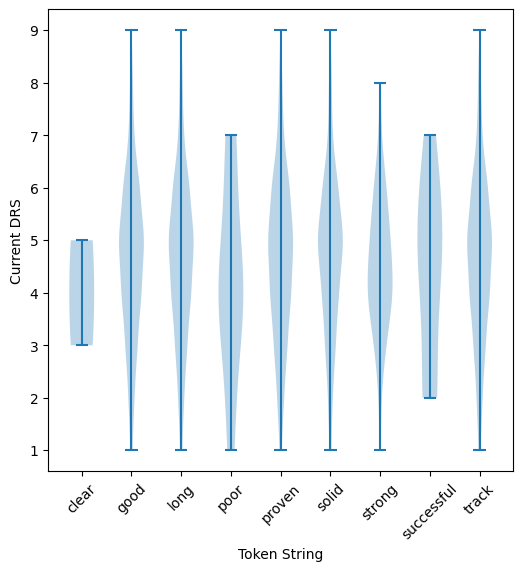

In [35]:
fig_data = [recent_innovation_df[recent_innovation_df['Token Str'] == ts]['Current DRS'].dropna() for ts in token_strings]
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
ax.violinplot(fig_data)
ax.set_xticks(range(1, len(token_strings)+1), labels=token_strings, rotation=45)
ax.set_xlabel('Token String')
ax.set_ylabel('Current DRS')

In [36]:
fig_df = recent_innovation_df[['Token Str', 'Current DRS', 'Score']].dropna()
fig_df['x'] = fig_df['Token Str'].apply(lambda ts: token_strings.index(ts) + 1)
fig_df['x'] = rand_jitter(fig_df['x'].to_numpy(), stdev=0.1)
fig_df

,Token Str,Current DRS,Score,x
0,track,6,0.863085,9.156229
1,proven,6,0.031375,8.988512
2,long,6,0.028682,9.118179
3,good,6,0.013843,9.047742
4,solid,6,0.012374,8.752872
...,...,...,...,...
1150,track,2,0.710864,8.935265
1151,long,2,0.064105,8.943803
1152,good,2,0.060930,9.032275
1153,proven,2,0.032237,8.866385


Text(0, 0.5, 'Current DRS')

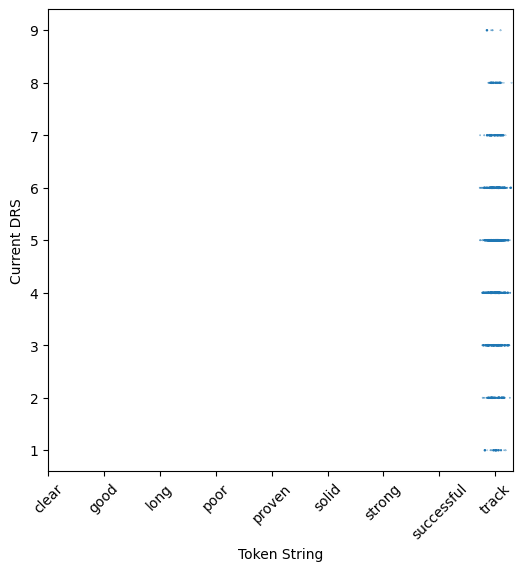

In [37]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
ax.scatter(fig_df['x'], fig_df['Current DRS'], s=fig_df['Score'])
ax.set_xticks(range(1, len(token_strings)+1), labels=token_strings, rotation=45)
ax.set_xlabel('Token String')
ax.set_ylabel('Current DRS')

Text(0, 0.5, 'Current DRS')

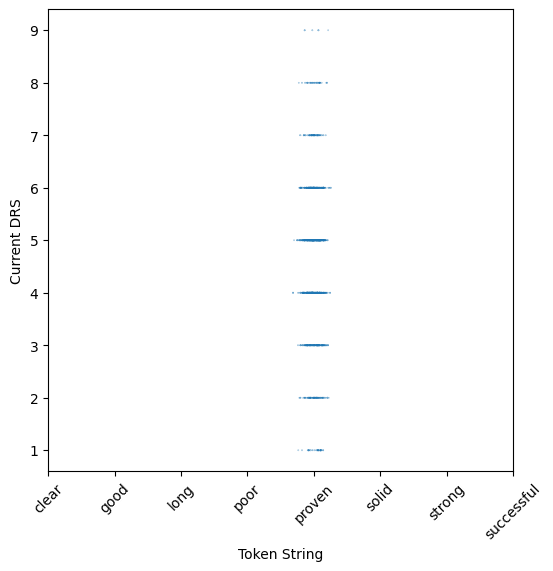

In [38]:
token_strings.remove('track')
fig_df = recent_innovation_df[recent_innovation_df['Token Str'].isin(token_strings)][['Token Str', 'Current DRS', 'Score']].dropna()
fig_df['x'] = fig_df['Token Str'].apply(lambda ts: token_strings.index(ts) + 1)
fig_df['x'] = rand_jitter(fig_df['x'].to_numpy(), stdev=0.1)
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
ax.scatter(fig_df['x'], fig_df['Current DRS'], s=fig_df['Score'])
ax.set_xticks(range(1, len(token_strings)+1), labels=token_strings, rotation=45)
ax.set_xlabel('Token String')
ax.set_ylabel('Current DRS')

Text(0, 0.5, 'Current DRS')

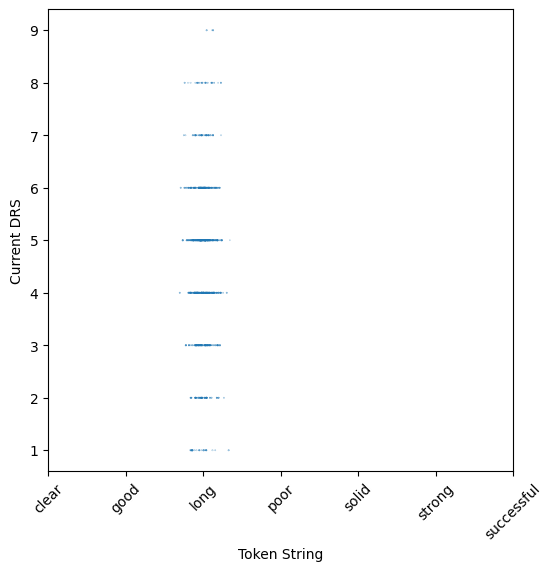

In [39]:
token_strings.remove('proven')
fig_df = recent_innovation_df[recent_innovation_df['Token Str'].isin(token_strings)][['Token Str', 'Current DRS', 'Score']].dropna()
fig_df['x'] = fig_df['Token Str'].apply(lambda ts: token_strings.index(ts) + 1)
fig_df['x'] = rand_jitter(fig_df['x'].to_numpy(), stdev=0.1)
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
ax.scatter(fig_df['x'], fig_df['Current DRS'], s=fig_df['Score'])
ax.set_xticks(range(1, len(token_strings)+1), labels=token_strings, rotation=45)
ax.set_xlabel('Token String')
ax.set_ylabel('Current DRS')

Text(0, 0.5, 'Current DRS')

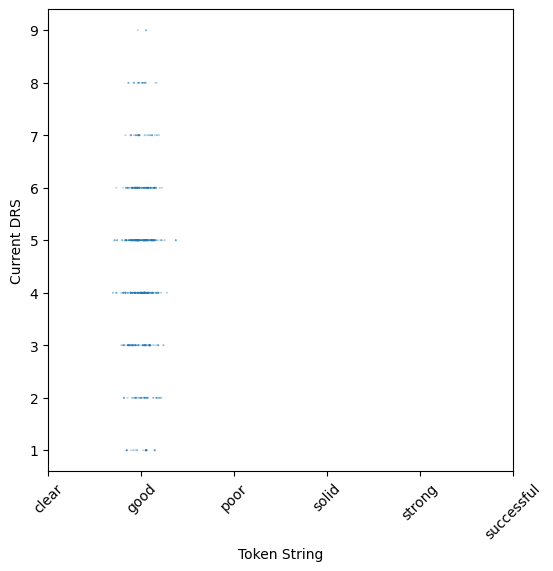

In [40]:
token_strings.remove('long')
fig_df = recent_innovation_df[recent_innovation_df['Token Str'].isin(token_strings)][['Token Str', 'Current DRS', 'Score']].dropna()
fig_df['x'] = fig_df['Token Str'].apply(lambda ts: token_strings.index(ts) + 1)
fig_df['x'] = rand_jitter(fig_df['x'].to_numpy(), stdev=0.1)
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
ax.scatter(fig_df['x'], fig_df['Current DRS'], s=fig_df['Score'])
ax.set_xticks(range(1, len(token_strings)+1), labels=token_strings, rotation=45)
ax.set_xlabel('Token String')
ax.set_ylabel('Current DRS')

In [41]:
token_results_df = recent_innovation_df.groupby('Token Str').agg({
    'Token Str': 'count',
    'Score': ['mean', 'min', 'max'],
    'Current DRS': ['mean', 'min', 'max']
    }).reset_index()
token_results_df

Token Str           Score                     Current DRS        
              count      mean       min       max        mean min max
0       clear     3  0.022775  0.016084  0.030642         4.0   3   5
1        good   230  0.086737  0.013843  0.415152    4.639269   1   9
2        long   230  0.069156  0.015365  0.167214    4.639269   1   9
3        poor    13  0.023320  0.017353  0.051741        4.25   1   7
4      proven   211  0.032722  0.012668  0.092020    4.648515   1   9
5       solid   182  0.025069  0.012374  0.056833    4.703488   1   9
6      strong    44  0.023724  0.010845  0.040535    4.488372   1   8
7  successful    11  0.020618  0.014082  0.033493    4.363636   2   7
8       track   231  0.673526  0.323275  0.863085    4.636364   1   9